In [1]:
import numpy as np
import matplotlib.pyplot as plt
from vae_definition import VAE
import torch

[Text(0.5, 1.0, 'Loss per iteration'),
 Text(0.5, 0, 'Iteration'),
 Text(0, 0.5, 'Loss [reconstruction + Kullback Liebler div]')]

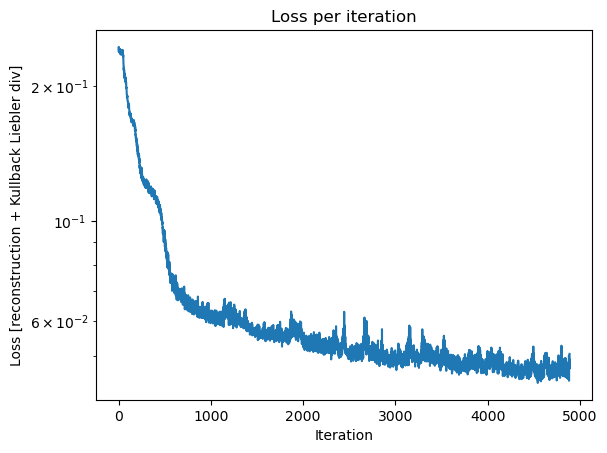

In [2]:
fig, ax = plt.subplots()
losses = np.load("vae_losses.npy")

ax.plot(losses)
ax.set(yscale="log")
ax.set(title="Loss per iteration", xlabel="Iteration", ylabel="Loss [reconstruction + Kullback Liebler div]")

torch.Size([100000, 48])
tensor([[ 9.1016e-02,  9.8600e-04,  1.0651e-01,  1.6054e-01],
        [ 1.1463e+00,  5.5898e-04, -9.0356e-02,  1.3827e+00],
        [-7.3074e-02,  8.1448e-04, -1.0474e-01, -4.7690e-02],
        ...,
        [-2.0871e+00, -7.4775e-04, -1.1851e-01, -1.3078e+00],
        [ 6.4720e-01,  9.3618e-04, -8.3750e-02,  9.8180e-01],
        [-2.0682e+00, -6.9326e-04, -1.8731e-01, -1.3299e+00]])


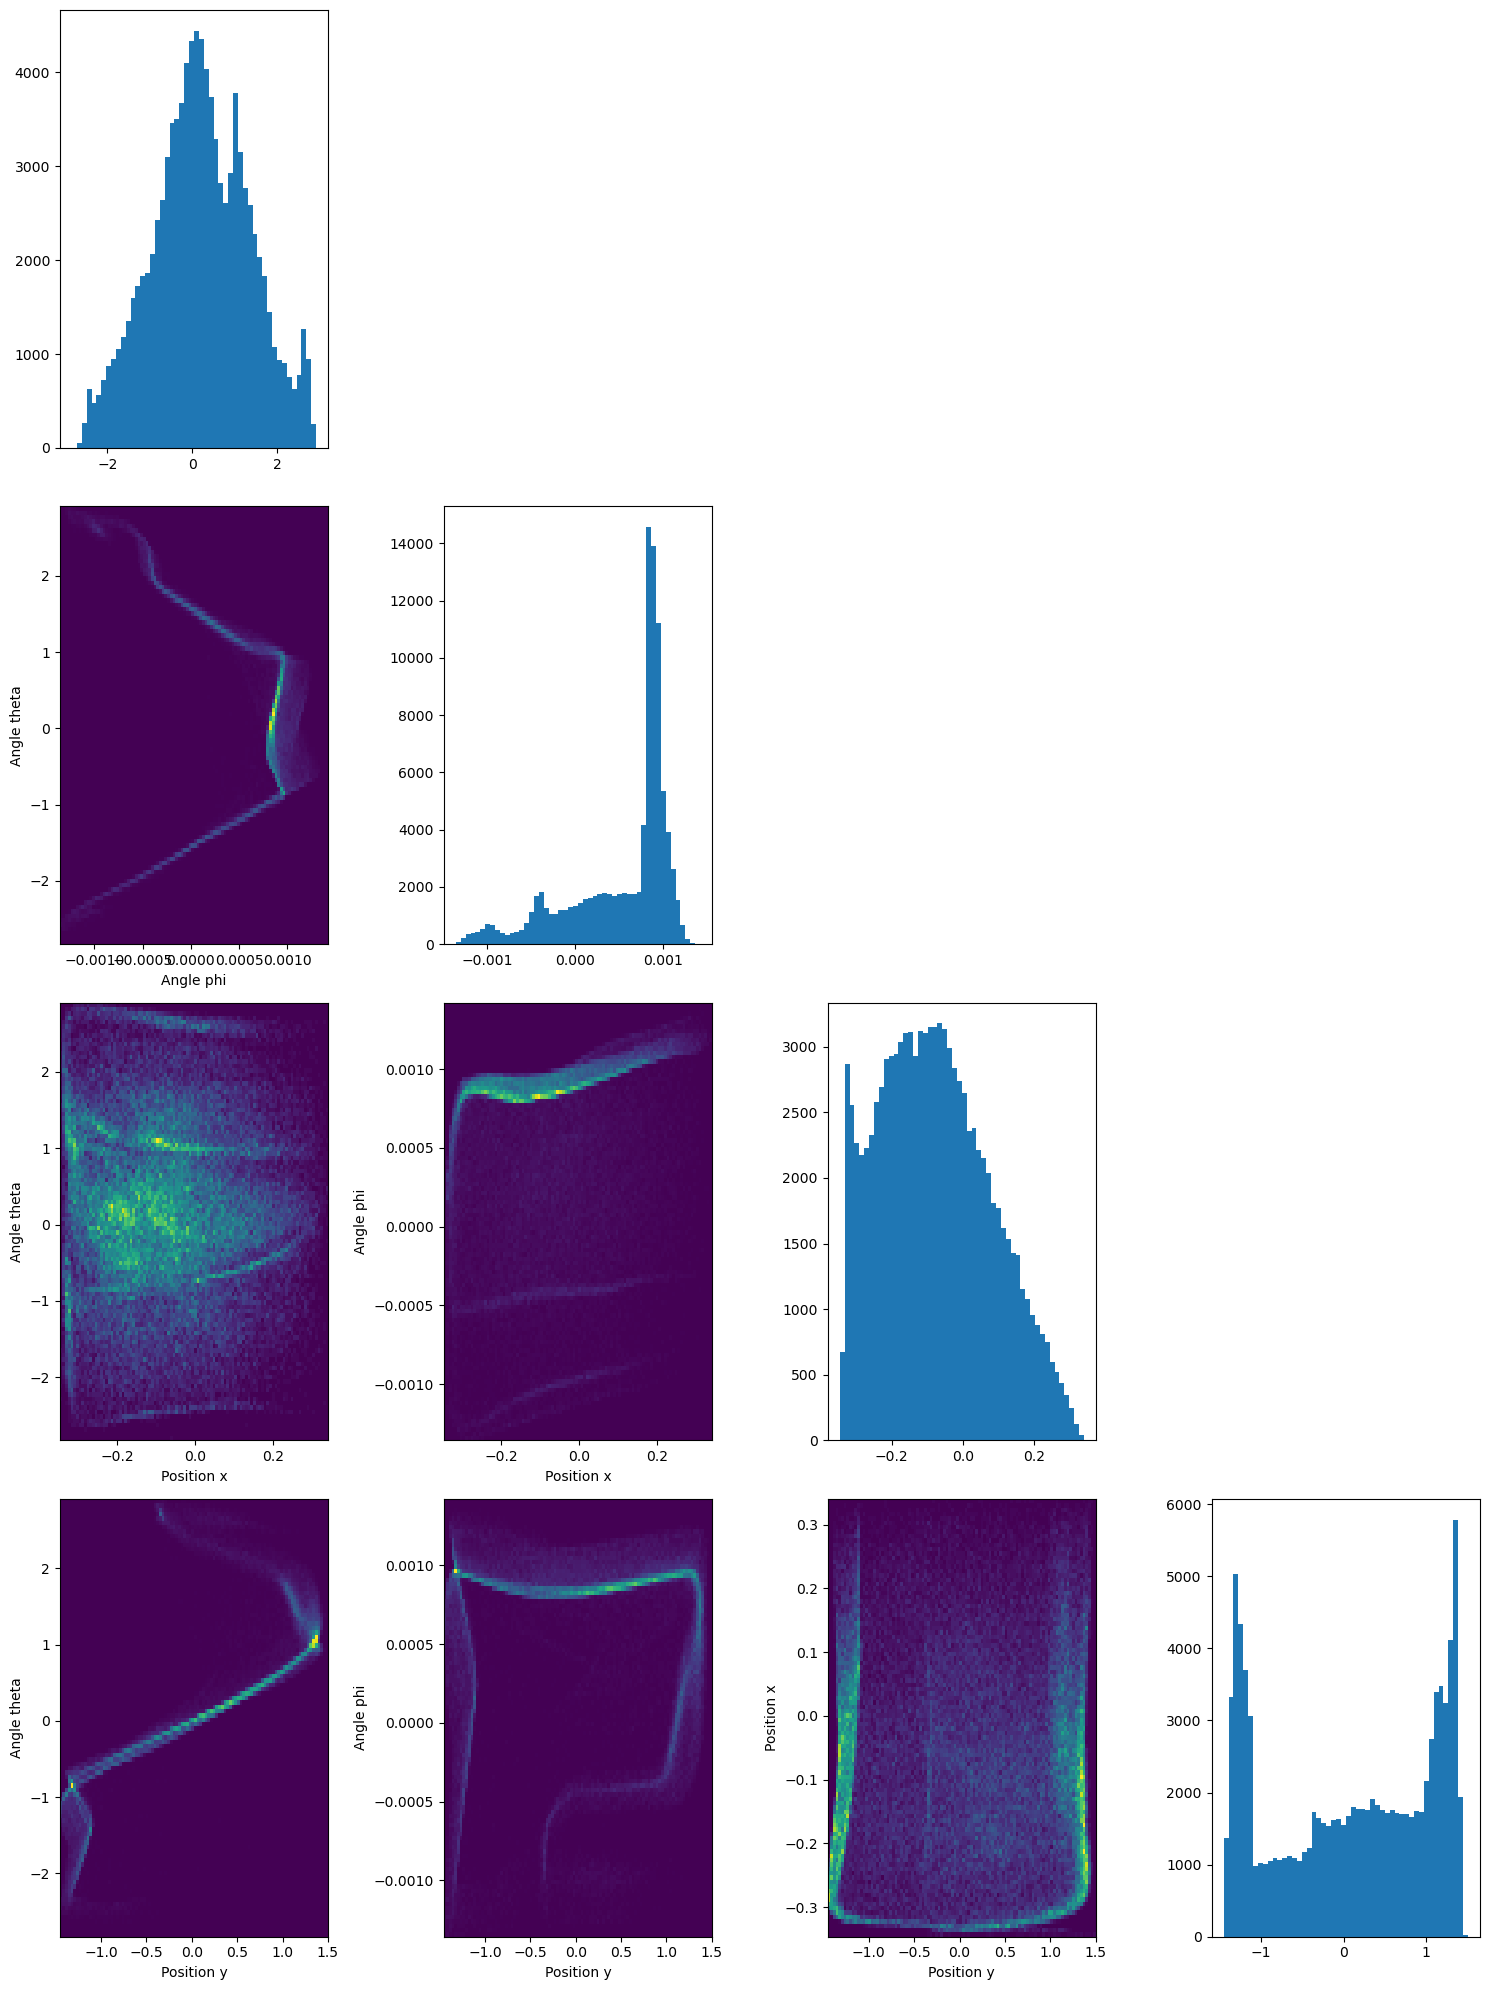

In [3]:
# sample_from_vae.py
device = "mps"

ckpt = torch.load("vae.pth", map_location=device)

vae = VAE().to(device)
vae.load_state_dict(ckpt["state_dict"])
vae.eval()

mins = ckpt["mins"].to(device)       
scales = ckpt["scales"].to(device)  


labels = ["Weight", "Energy", "Angle theta", "Angle phi", "Position x", "Position y"]
labels = ["Angle theta", "Angle phi", "Position x", "Position y"]
with torch.no_grad():
    z = torch.randn(100000,48).to(device)  # sample 1000 latent vectors
    print(z.shape)
    samples = vae.decode(z)              # synthetic data in [0,1]
    samples = samples.clamp(0,1)
    samples = samples * scales + mins
samples = samples.cpu()
print(samples.cpu())
input_dim = 4
fig, ax = plt.subplots(ncols=input_dim, nrows=input_dim, figsize=(15,20))
for i in range(input_dim):
    for j in range(input_dim):
        if j>i:
            ax[i,j].set_axis_off()
            continue
        if j==i:
            try:
                ax[i,j].hist(samples[:,i], bins=50)
            except Exception as e:
                print(e)
                ax[i,j].set_axis_off()
            continue
        ax[i,j].hist2d(samples[:,i], samples[:,j], bins=100)
        ax[i,j].set(xlabel=labels[i], ylabel=labels[j])
plt.tight_layout()